In [2]:
!pip install scikit-learn

In [3]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree

## Load Data

In [4]:
df = pd.read_csv("vehicles.csv")
df.head()

,Age,Gender,Income,Favorite Transport
0,5,female,NaN,bicycle
1,8,male,NaN,scooter
2,10,female,NaN,bicycle
3,14,male,NaN,metro
4,16,male,NaN,metro


## Clean Data

In [5]:
df.isnull().sum()

Age                   0
Gender                0
Income                6
Favorite Transport    0
dtype: int64

In [6]:
df.fillna({"Income": 0.0}, inplace=True)
df.head()

,Age,Gender,Income,Favorite Transport
0,5,female,0.0,bicycle
1,8,male,0.0,scooter
2,10,female,0.0,bicycle
3,14,male,0.0,metro
4,16,male,0.0,metro


## Encode Data

In [7]:
df["Gender"].unique()

array(['female', 'male'], dtype=object)

In [8]:
# Straightforward option of replacing values
# df.replace(["male", "female"], [0, 1], inplace=True)
# df.head()

In [9]:
# Smart option of replacing values
encoder = LabelEncoder()
df["Gender"] = encoder.fit_transform(df["Gender"])
df.head()

,Age,Gender,Income,Favorite Transport
0,5,0,0.0,bicycle
1,8,1,0.0,scooter
2,10,0,0.0,bicycle
3,14,1,0.0,metro
4,16,1,0.0,metro


In [10]:
df.dtypes

Age                     int64
Gender                  int32
Income                float64
Favorite Transport     object
dtype: object

## Train Model

In [11]:
# Model input
X = df.drop(columns="Favorite Transport")
X.head(1)

,Age,Gender,Income
0,5,0,0.0


In [12]:
# Model output
y = df["Favorite Transport"]
y.tail(1)

25    helicopter
Name: Favorite Transport, dtype: object

In [13]:
model = DecisionTreeClassifier()
model.fit(X, y)

DecisionTreeClassifier()

## Predict

In [14]:
test_df = pd.DataFrame({
    "Age": [12, 30, 75],
    "Gender": [0, 0, 1],
    "Income": [0.0, 4000, 50000]
})

model.predict(test_df)

array(['bicycle', 'car', 'helicopter'], dtype=object)

## Export Model

In [15]:
tree.export_graphviz(model, out_file="model.dot", feature_names=["Age", "Gender", "Income"], filled=True, class_names=sorted(y.unique()))

## Accuracy Evaluation

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X.shape

(26, 3)

In [17]:
X_train.shape

(20, 3)

In [18]:
X_test.shape

(6, 3)

In [19]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [20]:
X_test

,Age,Gender,Income
7,22,0,500.0
20,59,0,5500.0
17,53,0,1300.0
13,40,1,9000.0
16,49,1,8000.0
6,20,1,200.0


In [21]:
y_predicted = model.predict(X_test)
y_predicted

array(['metro', 'car', 'taxi', 'car', 'car', 'metro'], dtype=object)

In [22]:
acc = accuracy_score(y_test, y_predicted)
acc

0.6666666666666666

## Charts

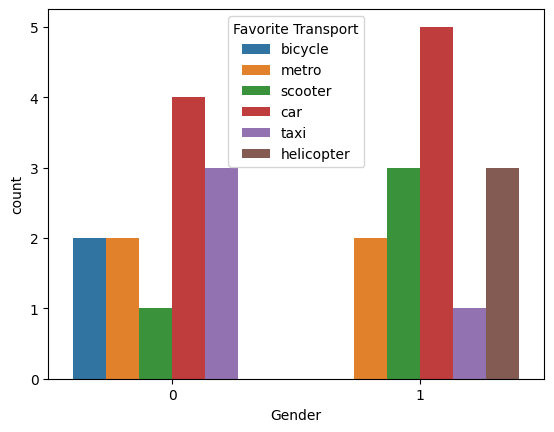

In [23]:
sn.countplot(x=df["Gender"], hue=df["Favorite Transport"])
plt.show()

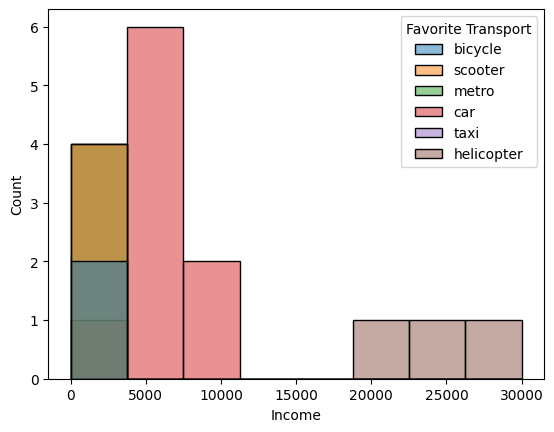

In [24]:
sn.histplot(x=df["Income"], hue=df["Favorite Transport"])
plt.show()